In [3]:
import os
import sys

# 実行環境の確認
if "google.colab" in sys.modules:
    print("✓ Running in Google Colab")
else:
    print("✗ Running locally (not Colab)")

print(f"Python version: {sys.version}")
print(f"Executable: {sys.executable}")
print(f"Working Directory: {os.getcwd()}")

✗ Running locally (not Colab)
Python version: 3.12.9 (main, Mar 17 2025, 21:01:58) [Clang 20.1.0 ]
Executable: /home/user/deep-learning-from-scratch-2/.venv/bin/python
Working Directory: /home/user/deep-learning-from-scratch-2/notebooks


In [5]:
# Colab で実行している場合、リポジトリをクローンする
#!git clone -b master https://github.com/AcademiXBase/deep-learning-from-scratch-2.git
#%cd deep-learning-from-scratch-2

In [4]:
# coding: utf-8
import sys
sys.path.append('..')

import numpy as np

from common.layers import MatMul, SoftmaxWithLoss
from common.trainer import Trainer
from common.optimizer import Adam
from common.util import preprocess, create_contexts_target, convert_one_hot

# word2vec
本章では、単語の分散表現（単語のベクトル表現）を獲得するための代表的な推論ベースの手法である「word2vec」の仕組みについて学びます。

## word2vecとは
ニューラルネットワークを用いて、単語同士の文脈的な関係性から単語の分散表現を獲得する手法全体のことを指します。代表的なネットワーク構造として以下の2つがあります。
- **CBOW (Continuous Bag-of-Words)**: 続くコードブロックで順伝播を実装しているように、周囲の単語（コンテキスト）から中央の単語（ターゲット）を推測するモデルです。
- **Skip-gram**: 中央の単語から周囲の単語を推測するモデルです（ノートブックの後半で `SimpleSkipGram` として実装されています）。
こうした推論の学習過程を通じて、入力側の重み行列（`W_in`）に単語の意味が凝縮されたベクトル（単語の分散表現）が獲得されます。

## word2vecの難しさ
本章のコードで実装している `SimpleCBOW` や `SimpleSkipGram` には計算量に関する弱点があります。
コーパスの規模や扱う語彙数（`vocab_size`）が実用規模まで大きくなると、巨大なパラメータの行列積（`MatMul`）や出力層のソフトマックス関数（`SoftmaxWithLoss`）の計算コストが膨大になり、学習の実効性においてボトルネックを引き起こします。

### 本章の目的
本格的な計算コストの問題に向き合う前に、まずは小さなスケールのコーパス（"You say goodbye and I say hello." のような短い文）を使った「シンプルなword2vec」を実装します。ネットワークの順伝播・逆伝播の挙動、コンテキストとターゲットデータの作成手法などを通して、word2vecがどのようなメカニズムで学習を行うのか、その「本質的な構造」を直感的に理解することが本章の目的です。
（※計算コストを解決して実用規模に拡張する方法は次章で扱います）


## カウントベースの方法の問題点

前章で学んだ**カウントベースの手法**（共起行列を作り、SVDで次元削減を行う手法）には、**計算量**という非常に大きな問題があります。

### $O(n^3)$ の計算コスト
カウントベースの手法では、コーパス全体の統計データ（共起行列など）を一度に処理する必要があります。特に、次元削減に用いる SVD（特異値分解）は、$n \times n$ の行列に対して **$O(n^3)$** の計算量がかかります。

もし語彙数 $n$ が $1,000,000$（100万語）のような実用的な規模になった場合、計算量は $1,000,000^3 = 10^{18}$ となり、現実的な時間やメモリで計算を完了させることはほぼ不可能です。

### 推論ベースの手法による解決策
一方で、これから学ぶ word2vec などの**推論ベースの手法**は、ニューラルネットワークを用いて**ミニバッチ単位で学習**を行います。
コーパス全体のデータを一度に計算（バッチ学習）するのではなく、少量の学習データを順番に見ながら、パラメータ（重み）を少しずつ更新していくアプローチです。これにより、巨大なコーパスであっても計算を分割し、GPUなどを使って並列に効率よく学習を進めることが可能になります。


## 

## CBOW の順伝播：最小構成での動作確認

このセクションでは、学習前のランダムな重みを用いて、CBOW モデルがどのように「入力からスコア」を算出するのか、その内部処理をステップバイステップで確認します。

### 1. 入力の定義（one-hot ベクトル）
まず、文脈となる2つの単語（`c0`, `c1`）を準備します。
* **データ形式**: 語彙数 7 の **one-hot ベクトル**（特定の要素だけが 1 で他が 0 の配列）として表現します。
* **意味**: one-hot ベクトルを重み $W_{in}$ に掛け合わせる（`MatMul`）操作は、数学的には重み行列から特定の行を抽出することと同義であり、これが **「単語の埋め込み（Embedding）」** に相当します。

### 2. 文脈の集約（中間表現 $h$ の生成）
2つの単語から得られた情報を1つのベクトルにまとめます。
* **埋め込みの取得**: $c0 \rightarrow h0$, $c1 \rightarrow h1$ と変換。
* **平均化**: $h = (h0 + h1) \times 0.5$
* **役割**: この平均ベクトル $h$ が、その地点における **「文脈全体の意味」** を凝縮した中間表現となります。



### 3. スコアの算出（出力層）
中間表現 $h$ から、語彙全体（7単語）に対する「出やすさ」を計算します。
* **出力計算**: $s = h \cdot W_{out}$
* **スコアの性質**: 出力される `s` はまだ確率（0〜1）ではなく、**生のスコア（Logits）** です。
* **次のステップ**: 通常の学習・推論では、このスコアに Softmax 関数を適用することで、「どの単語が中央にくる確率が最も高いか」を判定します。

---

### 処理の流れ：視覚的まとめ

| 段階 | 処理内容 | 数学的解釈 |
| :--- | :--- | :--- |
| **Input** | $c0, c1$ | 単語 ID の one-hot 表現 |
| **Embedding** | $h0, h1$ | $W_{in}$ からの特定の行抽出 |
| **Hidden** | $h = \text{mean}(h0, h1)$ | 文脈のベクトル合成 |
| **Output** | $s$ | 語彙ごとのスコア算出 |

> **ポイント**
> 現段階では重みがランダムなため、出力されるスコアに意味はありません。しかし、この「ベクトルを集約して写像する」という計算フローこそが、CBOW モデルの中心です。

In [5]:
# サンプルのコンテキストデータ
c0 = np.array([[1, 0, 0, 0, 0, 0, 0]])
c1 = np.array([[0, 0, 1, 0, 0, 0, 0]])

# 重みの初期化
W_in = np.random.randn(7, 3)
W_out = np.random.randn(3, 7)

# レイヤの生成
in_layer0 = MatMul(W_in)
in_layer1 = MatMul(W_in)
out_layer = MatMul(W_out)

# 順伝搬
h0 = in_layer0.forward(c0)
h1 = in_layer1.forward(c1)
h = 0.5 * (h0 + h1)
s = out_layer.forward(h)
print(s)


[[ 0.72055095  0.1188867   0.87308281 -0.48238997  0.02356887  0.21550521
  -0.31202928]]


## `SimpleCBOW` クラスの実装

CBOW（Continuous Bag-of-Words）モデルは、周囲の単語（コンテキスト）から中央の単語（ターゲット）を予測するニューラルネットワークです。本クラスでは、その基本構造を実装します。

### 1. 初期化 (`__init__`)
モデルの重みとレイヤの準備を行います。

* **重みの初期化**:
    * `W_in`: 入力側の重み。学習完了後は `self.word_vecs` として単語の分散表現（ベクトル）になります。
    * `W_out`: 出力側の重み。中間表現から各単語のスコアを算出します。
* **レイヤの構成**:
    * **入力層**: 2つのコンテキスト（左右の語）に対して、同じ `W_in` を共有する `MatMul` レイヤを配置します。
    * **出力層**: `MatMul` レイヤでスコアを算出し、最後に `SoftmaxWithLoss` レイヤで損失を計算します。



### 2. 順伝播 (`forward`)
「文脈語 → 埋め込み → 平均 → スコア → 損失」という流れで処理が進みます。

1.  **入力**: `contexts[:, 0]` と `contexts[:, 1]` を別々の入力層に投入します。
2.  **平均化**: 2つの入力層から得られたベクトルを合算し、**0.5を掛けて平均**をとることで中間表現 $h$ を生成します。
3.  **スコア算出**: 中間表現 $h$ を出力層に通し、各単語の出現確率（スコア）を求めます。
4.  **損失計算**: ターゲット語（正解ラベル）との比較から、現在のモデルの誤差（Loss）を算出します。

### 3. 逆伝播 (`backward`)
誤差を各パラメータに伝播させ、勾配を計算します。

* **勾配の分配**:
    出力層から戻ってきた勾配に対して、順伝播での「平均化」と整合性を保つため **0.5倍** 処理を行います。この縮小された勾配を、2つの入力層へ等しく分配（コピー）します。
* **パラメータの集約**:
    各レイヤが持つ `params`（重み）と `grads`（勾配）をリストにまとめます。これにより、`Trainer` クラスなどの外部モジュールから一括で重みの更新ができるようになります。

---

### まとめ：データの流れ
| ステップ | 内容 | 備考 |
| :--- | :--- | :--- |
| **Input** | 2つのコンテキスト語 | ID形式で入力 |
| **Hidden** | $h = \frac{1}{2}(v_{context1} + v_{context2})$ | ベクトルの平均をとる |
| **Output** | Softmaxスコア | 語彙数分の確率分布 |
| **Loss** | 交差エントロピー誤差 | ターゲット語との乖離を数値化 |


![alt text](images/cbow.png)

In [28]:
class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # レイヤの生成
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # すべての重みと勾配をリストにまとめる
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss

    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None


## `SimpleCBOW` の学習サイクル

このセクションでは、定義した `SimpleCBOW` モデルに、短いコーパス（`You say goodbye and I say hello.`）を学習させる一連の流れを解説します。

### 1. データの準備（プリプロセッシング）
学習を開始する前に、テキストをコンピュータが扱える数値形式に加工します。

* **`preprocess`**: 文字列を単語IDのリスト（`corpus`）へ変換します。同時に、単語とIDを紐付ける辞書（`word_to_id`, `id_to_word`）を生成します。
* **`create_contexts_target`**: 教師データを作成します。
    * **Contexts**: ターゲットの周囲にある単語（`window_size = 1` の場合、左右1語ずつ）。
    * **Target**: 推測対象となる中央の単語。
* **`convert_one_hot`**: 各単語IDを **one-hotベクトル** に変換します。これは簡易的な `MatMul` 実装において計算をスムーズに行うための処理です。

### 2. モデルの初期化と学習の実行
学習の司令塔となるコンポーネントを準備し、最適化を行います。

* **コンポーネントの構成**:
    * **モデル**: `SimpleCBOW` クラス。
    * **最適化 (Optimizer)**: `Adam` を採用し、効率的に重みを更新します。
    * **学習制御 (Trainer)**: `fit` メソッドを呼び出し、ミニバッチ学習（データを小分けにして反復学習）を実行します。



### 3. 学習結果の評価と可視化
学習が正しく行われたかを、以下の2点から確認します。

1.  **損失の推移 (`trainer.plot`)**: 
    学習中の損失（Loss）が時間の経過とともに減少しているかを確認します。損失の低下は、モデルが「文脈からターゲットを予測する能力」を高めている証拠です。
2.  **単語ベクトルの確認 (`model.word_vecs`)**: 
    学習後の重み $W_{in}$ を参照します。非常に短い文章ですが、「似た文脈で使われる単語は、ベクトル空間上でも近い位置に配置される」という word2vec の特性の片鱗を観察できます。

---

### 学習フローのまとめ

| ステップ | 実行内容 | 目的 |
| :--- | :--- | :--- |
| **データ成形** | ID化・教師データ分割・One-hot化 | モデルが計算可能な形式にする |
| **学習** | `Trainer.fit()` | 誤差逆伝播法により重みを最適化する |
| **評価** | Lossプロット・ベクトル抽出 | モデルの精度と単語の意味理解を確認する |


| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

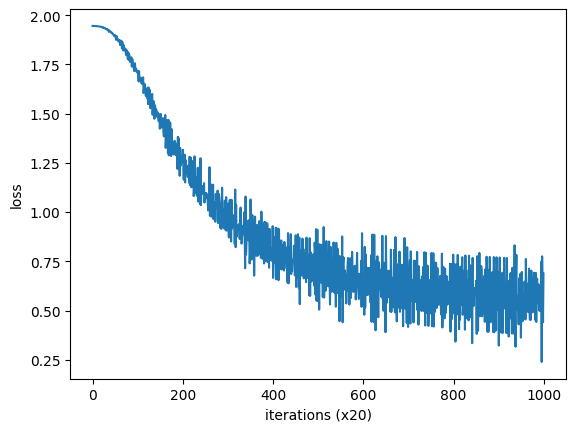

you [ 1.1949086 -1.1849107  1.2394266  1.1430067  1.1022253]
say [-1.2422338   0.34193626 -0.29265743 -1.2552483  -1.2463247 ]
goodbye [ 0.8199297  -0.7293061   0.620882    0.7968566   0.90657324]
and [-1.0468667  1.5868096 -1.588776  -1.0523239 -1.058118 ]
i [ 0.81718445 -0.74134344  0.6055642   0.81351626  0.88594574]
hello [ 1.1639912 -1.1727108  1.2584381  1.138977   1.0978659]
. [-1.078169  -1.5444281  1.531094  -1.0985096 -1.0903208]


In [29]:
window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])


## `SimpleSkipGram` クラスの実装

Skip-gram モデルは、CBOW とは対照的に「ターゲット語から周囲の文脈語を予測」するニューラルネットワークです。

### 1. 初期化 (`__init__`)
入力が1つ、出力が複数になる Skip-gram 特有の構造を準備します。

* **重みの構成**:
    * `W_in` / `W_out`: CBOW と同様の役割を持ちますが、入力層はターゲット語1語を受け取るため **1つだけ** となります。
* **損失層の重複**:
    * Skip-gram では、1つの入力に対して複数の文脈語を予測します。そのため、コンテキストの数（`window_size` × 2）だけ `SoftmaxWithLoss` レイヤを用意します。



### 2. 順伝播 (`forward`)
「ターゲット語 → 埋め込み → スコア算出 → 各文脈語への予測誤差」という流れで進みます。

1.  **入力**: 中央のターゲット語を `in_layer`（入力層）に通します。
2.  **スコア算出**: 中間表現から、語彙全体に対するスコア `s` を計算します。
3.  **誤差の合算**: 得られた同一のスコア `s` を各損失層へ分配し、それぞれの文脈語（例えば左隣の語と右隣の語）に対する損失 `l1`, `l2` を求めます。最終的な損失はこれらを足し合わせた $L = l1 + l2$ となります。

### 3. 逆伝播 (`backward`)
複数の予測結果から得られた勾配を、1つの入力層へ集約します。

* **勾配の合算**:
    各損失層から戻ってきた勾配（`ds1`, `ds2`）を足し合わせ、出力層へ戻します。
* **重みの更新**:
    1つの入力単語ベクトルが「複数の周辺語」を同時に説明できるように学習が進みます。これにより、一般的に CBOW よりも単語間の関連性をより精緻に捉えられる傾向があります。

---

### CBOW と Skip-gram の比較まとめ

| 特徴 | CBOW | Skip-gram |
| :--- | :--- | :--- |
| **予測の方向** | 文脈 $\rightarrow$ **ターゲット** | ターゲット $\rightarrow$ **文脈** |
| **入力層の数** | 複数（コンテキスト数） | 1つ |
| **損失層の数** | 1つ | 複数（コンテキスト数） |
| **学習の特徴** | 計算が速い | 低頻度語の精度が良い傾向 |

![alt text](images/skip-gram.png)

In [10]:
class SimpleSkipGram:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 重みの初期化
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # レイヤの生成
        self.in_layer = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer1 = SoftmaxWithLoss()
        self.loss_layer2 = SoftmaxWithLoss()

        # すべての重みと勾配をリストにまとめる
        layers = [self.in_layer, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # メンバ変数に単語の分散表現を設定
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)
        s = self.out_layer.forward(h)
        l1 = self.loss_layer1.forward(s, contexts[:, 0])
        l2 = self.loss_layer2.forward(s, contexts[:, 1])
        loss = l1 + l2
        return loss

    def backward(self, dout=1):
        dl1 = self.loss_layer1.backward(dout)
        dl2 = self.loss_layer2.backward(dout)
        ds = dl1 + dl2
        dh = self.out_layer.backward(ds)
        self.in_layer.backward(dh)
        return None


## `SimpleSkipGram` の学習サイクル

このセクションでは、先ほど実装した `SimpleSkipGram` クラスを用い、CBOW と同じ条件で学習を行います。モデル構造の変化が学習結果にどう影響するかを確認しましょう。

### 1. 学習設定の共有
比較を容易にするため、ハイパーパラメータやデータ処理は CBOW の学習時と共通のものを使用します。

* **共通の設定**:
    * `window_size`: 1（左右1語ずつを文脈とする）
    * `hidden_size`: 中間層の次元数
    * `batch_size` / `max_epoch`: 学習のバッチサイズと反復回数
* **データの流用**:
    `preprocess` や `create_contexts_target` で作成したデータはそのまま使えますが、Skip-gram では**入力と出力の役割が逆転**（`target` が入力、`contexts` が正解ラベル）して扱われます。

### 2. 学習の実行と挙動の違い
`Trainer` クラスを用いて学習を回し、損失（Loss）の推移を観測します。

* **多出力の学習**:
    1回の `forward` で中央語から複数の周辺語を同時に予測するため、CBOW と比較して学習の進み方（損失の減り方）に違いが現れます。
* **最適化**:
    CBOW と同様に `Adam` を用い、複数の損失層から合算された勾配をもとに重みを効率よく更新します。



### 3. 学習済みベクトルの比較
最後に、獲得した単語の分散表現（`word_vecs`）を確認します。

* **埋め込みの特性**:
    CBOW で得られたベクトルと数値は異なりますが、「似た文脈で出現する単語同士が近くに集まる」という本質的な傾向は共通しています。
* **比較のポイント**:
    短いコーパスにおいて、特定の単語（例：`say` と `goodbye`）がどのように空間配置されるか、CBOW 版の結果と比較することでモデルごとの「癖」を観察できます。

---

### CBOW と Skip-gram の学習フロー比較

| 項目 | CBOW の学習 | Skip-gram の学習 |
| :--- | :--- | :--- |
| **入力データ** | 周辺語（2語） | 中央語（1語） |
| **予測対象** | 中央語（1語） | 周辺語（2語） |
| **1回あたりの予測数** | 1つ | 2つ（`window_size=1` の場合） |
| **学習の傾向** | 複数の単語から1つの正解を導くため、安定しやすい | 1つの単語から複数の文脈を推論するため、学習がより詳細になる |

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 3.89
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 3.88
| epoch 21 |  iter 1 / 2 | ti

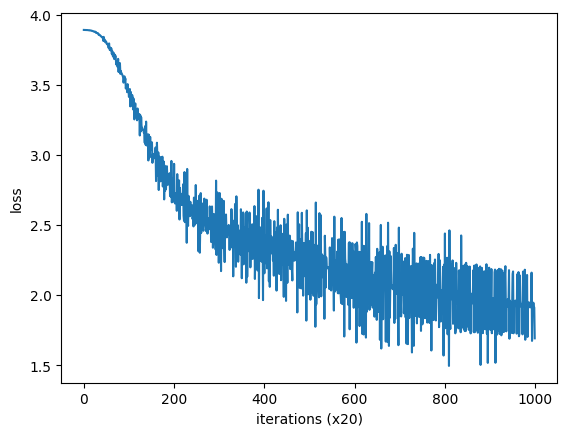

you [-0.00355315  0.0035786   0.01852129 -0.00853204  0.0039879 ]
say [-0.14064445 -1.2141579  -0.7338512  -0.11477444  0.883025  ]
goodbye [ 0.7988349   1.2097666   0.61890894  0.7995839  -0.6541257 ]
and [-1.2826322  -0.25392565 -1.1219113  -1.2815739   1.0586748 ]
i [ 0.80699503  1.2157587   0.6331      0.79337204 -0.64717823]
hello [ 0.7819058  -0.90558517  1.0966868   0.8178611  -1.0991074 ]
. [-0.02307633 -0.00053162 -0.00045793  0.00230115  0.01098533]


In [11]:
window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleSkipGram(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])

## 本章のまとめ

本章では、単語の分散表現を獲得するための代表的な推論ベースの手法である **word2vec** の仕組みと、そのシンプルなモデルの実装について学びました。

- **推論ベースの手法の利点**: コーパス全体を1回のSVDで処理するカウントベースの手法とは異なり、ニューラルネットワークを用いてミニバッチごとに学習（推論）を行うことで、パラメータを段階的に更新しながら単語の分散表現を獲得します。
- **CBOW と Skip-gram**: word2vec には2つの代表的なモデルがあります。
  - **CBOW (Continuous Bag-of-Words)**: 複数の周辺の単語（コンテキスト）から、中央の単語（ターゲット）を推測します。
  - **Skip-gram**: 中央の単語（ターゲット）から、複数の周辺の単語（コンテキスト）を推測します。
- **単語の分散表現**: 学習が完了したネットワークの入力層の重み（$W_{in}$）には、単語の意味が凝縮されたベクトル（単語の分散表現）がエンコードされます。似た文脈で使われる単語は、ベクトル空間上でも近い位置に配置されます。

**次章への展望**
本章で実装した `SimpleCBOW` と `SimpleSkipGram` は、word2vec の本質的な仕組みを理解するための最小構成でした。しかし、扱う語彙数（`vocab_size`）が数万〜数百万といった実用的な規模になると、巨大な行列の積や Softmax 関数の計算量が膨大になり、現実的な時間で学習が終わらないという構造的なボトルネックを抱えています。

次章（第4章）では、この計算コストの問題を解決するための **「Embedding レイヤ」** と **「Negative Sampling（負例サンプリング）」** という重要なテクニックを導入し、大規模なコーパスでも高速に学習できる「本物の word2vec」へと改良していきます。
